In [1]:
import matplotlib.pyplot as plt
from MedtronicPerceptAnalysisTool import PatientDatasetRegistry
from MedtronicPerceptAnalysisTool.plotter.all_patients.all_patients import plot_freqRange_powerMean_of_treatment1_2_normalized_intertreatment_baseline
from MedtronicPerceptAnalysisTool.utility.constants import FrequencyRange
import pandas as pd
import numpy as np
from MedtronicPerceptAnalysisTool.plotter.all_patients.all_patients import plot_all_hemi_type_inter
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind, wilcoxon, ranksums, mannwhitneyu, ttest_rel
from matplotlib import cm as cmap
import dateutil 
import copy
viridis = cmap.get_cmap('gist_ncar', 15)
import warnings
import statsmodels.api as sm
import statsmodels.formula.api as smf
warnings.filterwarnings("ignore", category=DeprecationWarning) 

df_all = PatientDatasetRegistry().all_dataframe_lfp()

freq_range = FrequencyRange.Beta.value
nopeaks = [2,3,5,8,9]

C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\3772305966.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cmap.get_cmap('gist_ncar', 15)


In [2]:
def round1000(value):
    return np.round(value*100)/100

def round10000p(value):
    return np.round(value*10000)/10000

def gatherPSD(data, p1 = 12, p2 = 30):
    r = data["PSD_(1, 100)"]
    gather = []
    for i,d in enumerate(r):
        w1 = int(np.argwhere(d.frequency==p1))
        w2 = int(np.argwhere(d.frequency==p2))
        gather.append(d.PSD[w1:w2])
    g = np.array(gather)
    return g

def custombox(data,position, scatter = False, sds = False, w = [.5], scattersize = 2, color = 'k',alpha=.5):
    data = np.array(data).flatten()
    plt.boxplot(np.array(data), positions= [position], widths = w)
    if scatter:
        r = np.random.randn(data.shape[0])/30
        plt.scatter(data*0+position+r,data,scattersize,color,alpha=alpha)
    plt.plot([position-w[0]/2, position+w[0]/2],[np.mean(data), np.mean(data)],'g')
    if sds:
        plt.plot([position-w[0]/2, position+w[0]/2],[np.mean(data)-np.std(data)/np.sqrt(data.shape[0]), np.mean(data)-np.std(data)/np.sqrt(data.shape[0])],'g', alpha=.5)
        plt.plot([position-w[0]/2, position+w[0]/2],[np.mean(data)+np.std(data)/np.sqrt(data.shape[0]), np.mean(data)+np.std(data)/np.sqrt(data.shape[0])],'g', alpha=.5)

def customUnravel(data):
    meow = []
    for i in data:
        for j in i:
            meow.append(j)
    return np.array(meow).flatten()

def exportFigure(name):
    plt.savefig(name+".svg")
    plt.savefig(name+".png")

def printTtest(data1,data2,name1,name2):
    a = stats.ttest_ind(data1.flatten(),data2.flatten())
    print(name1," vs. ",name2)
    
    if a.pvalue <= 0.05:
        print("Significant, p: ", a.pvalue)
    else:
        print("Non-significant, p: ", a.pvalue)
    
    print(name1, " mean is: ", round1000(np.mean(data1)), " SEM is: ", round1000(np.std(data1)/np.sqrt(len(data1))), " Median is: ", round1000(np.median(data1)))
    print(name2, " mean is: ", round1000(np.mean(data2)), " SEM is: ", round1000(np.std(data2)/np.sqrt(len(data2))), " Median is: ", round1000(np.median(data2)))
    print("")
    return a.pvalue

def statoutLMEM(model):  
    rvs_change = model.params["Condition[T.C) RVS]"]
    rvs_se = model.bse["Condition[T.C) RVS]"]
    rvs_p = model.pvalues["Condition[T.C) RVS]"]
    ci = model.conf_int(alpha=0.1)
    print("\nDBS-off Mean: "  ,     round1000(model.params["Intercept"]),\
          "\nDBS-off SEM: ",      round1000(model.bse["Intercept"]),\
          "\nDBS-off CI: ",      "[",round1000(ci[0][0]),", ",round1000(ci[1][0]),"]"\
          "\n")
    print("\nAll-on Mean: "  ,     round1000(model.params["Condition[T.B) Allon]"]+model.params["Intercept"]),\
          "\nAll-on SEM: ",      round1000(model.bse["Condition[T.B) Allon]"]),\
          "\nAll-on CI: ",      "[",round1000(ci[0][1]),", ",round1000(ci[1][1]),"]"\
          "\n")
    print("\nRVS Mean: "  ,    round1000(model.params["Condition[T.C) RVS]"]+model.params["Intercept"]),\
          "\nRVS SEM: ",      round1000(model.bse["Condition[T.C) RVS]"]),\
          "\nRVS CI: ",      "[",round1000(ci[0][2]),", ",round1000(ci[1][2]),"]"\
          "\n")
    contrast = "Condition[T.C) RVS] - Condition[T.B) Allon] = 0"
    wald_test = model.wald_test(contrast)
    print("\nDBS-off vs. All-on: ", round10000p( model.pvalues["Condition[T.B) Allon]"]),\
          "\nDBS-off vs. RVS: ", round10000p( model.pvalues["Condition[T.C) RVS]"]),\
          "\nAll-on vs. RVS: ", round10000p(wald_test.pvalue),\
          "\n")  
    return 0

def statout(base,allon,rvs):
    print("DBS-off mean: "  ,     round1000(np.mean(base)),\
          "\nDBS-off median: ",   round1000(np.median(base)),\
          "\nDBS-off st. dev.: ", round1000(np.std(base)),\
          "\nDBS-off SEM: ",      round1000(np.std(base)/np.sqrt(len(base))),\
          "\n")
    print("All-on mean: "  ,     round1000(np.mean(allon)),\
          "\nAll-on median: ",   round1000(np.median(allon)),\
          "\nAll-on st. dev.: ", round1000(np.std(allon)),\
          "\nAll-on SEM: ",      round1000(np.std(allon)/np.sqrt(len(allon))),\
          "\n")
    print("RVS mean: "  ,     round1000(np.mean(rvs)),\
          "\nRVS median: ",   round1000(np.median(rvs)),\
          "\nRVS st. dev.: ", round1000(np.std(rvs)),\
          "\nRVS SEM: ",      round1000(np.std(rvs)/np.sqrt(len(rvs))),\
          "\n")
    return 0

def gen_DataSliceMean(data, p1 = 13, p2 = 30, baseCut = -3, testCut = -6, toMax = False):
    dr = []
    
    base = data.loc[(data["TreatmentBranch"] == "dbs_off")]
    allon = data.loc[(data["TreatmentBranch"] == "all_on")]
    rvs = data.loc[(data["TreatmentBranch"] == "rvs")]
    
    mg = np.ndarray(len(np.unique(base["PatientNumber"]))*2)
    maxmult = np.ndarray(len(np.unique(base["PatientNumber"]))*2)
    xi = 0
    for x,p in enumerate(base.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            
            mg[xi] = np.mean(gather[baseCut:])
            #if toMax:
            #    mg[xi] = np.mean(np.max(gather[-baseCut:],axis=1))
            gather = gather/mg[xi]
            if toMax:
                maxmult[xi] = np.mean(np.max(gather[baseCut:,:],axis=0))
                maxmult[xi] = 1
                gather = (gather-maxmult[xi])/maxmult[xi]*100
            else:
                gather = (gather-1)/1*100
            if toMax:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "A) Baseline",
                "Time": np.arange(1,4),
                "Outcome": (np.mean(np.max(gather[baseCut:,:],axis=1)))})
            else:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "A) Baseline",
                "Time": np.arange(1,4),
                "Outcome": (np.mean(np.mean(gather[baseCut:,:],axis=1)))})
            xi += 1
            
    
    xi = 0
    for x,p in enumerate(allon.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            
            if toMax:
                gather = (gather-maxmult[xi])/maxmult[xi]*100
            else:
                gather = (gather-1)/1*100
                
            if toMax:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "B) Allon",
                "Time": np.arange(1,len(np.max(gather[testCut:,:],axis=1))),
                "Outcome": (np.mean(np.max(gather[testCut:,:],axis=1)))})
            else:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "B) Allon",
                "Time": np.arange(1,len(np.max(gather[testCut:,:],axis=1))),
                "Outcome": (np.mean(np.mean(gather[testCut:,:],axis=1)))})
            xi += 1
    
    xi = 0
    for x,p in enumerate(rvs.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            
            if toMax:
                gather = (gather-maxmult[xi])/maxmult[xi]*100
            else:
                gather = (gather-1)/1*100
                
            if toMax:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "C) RVS",
                "Time": np.arange(1,len(np.max(gather[testCut:,:],axis=1))),
                "Outcome": (np.mean(np.max(gather[testCut:,:],axis=1)))})
            else:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "C) RVS",
                "Time": np.arange(1,len(np.max(gather[testCut:,:],axis=1))),
                "Outcome": (np.mean(np.mean(gather[testCut:,:],axis=1)))})
            xi += 1   
            
    dataReturn = pd.DataFrame(dr)
    dataReturn = dataReturn.explode("Outcome")
    dataReturn["Outcome"] = pd.to_numeric(dataReturn["Outcome"], errors="coerce")
    return dataReturn

def gen_allSession_Data(data, p1 = 13, p2 = 30, baseCut = -3, testCut = -6, toMax = False):
    base = data.loc[(data["TreatmentBranch"] == "dbs_off")]
    allon = data.loc[(data["TreatmentBranch"] == "all_on")]
    rvs = data.loc[(data["TreatmentBranch"] == "rvs")]
    
    mg = np.ndarray(len(np.unique(base["PatientNumber"]))*2)
    maxmult = np.ndarray(len(np.unique(base["PatientNumber"]))*2)
    baseValues = []
    baseMeans =  []
    xi = 0
    for x,p in enumerate(base.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            
            mg[xi] = np.mean(gather[baseCut:])
            #if toMax:
            #    mg[xi] = np.mean(np.max(gather[-baseCut:],axis=1))
            gather = gather/mg[xi]
            if toMax:
                maxmult[xi] = np.mean(np.max(gather[-baseCut:,:],axis=0))
                maxmult[xi] = 1
                gather = (gather-maxmult[xi])/maxmult[xi]*100
            else:
                gather = (gather-1)/1*100
            if toMax:
                baseValues.append(np.max(gather[baseCut:,:],axis=1))
                baseMeans.append( np.mean(np.max(gather[baseCut:,:],axis=1)) )
            else:
                baseValues.append(np.mean(gather[baseCut:,:],axis=1))
                baseMeans.append( np.mean(np.mean(gather[baseCut:,:],axis=1)) )
            xi += 1
    baseValues = customUnravel(baseValues)
    baseMeans =  np.array(baseMeans).flatten()
    
    allValues = []
    allMeans = []
    xi = 0
    for x,p in enumerate(allon.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            
            if toMax:
                gather = (gather-maxmult[xi])/maxmult[xi]*100
            else:
                gather = (gather-1)/1*100
                
            if toMax:
                allValues.append(np.max(gather[testCut:,:],axis=1))
                allMeans.append( np.mean(np.max(gather[testCut:,:],axis=1)) )
            else:
                allValues.append(np.mean(gather[testCut:,:],axis=1))
                allMeans.append( np.mean(np.mean(gather[testCut:,:],axis=1)) )
            
            xi += 1
    allValues = customUnravel(allValues)
    allMeans =  np.array(allMeans).flatten()
    
    rvsValues = []
    rvsMeans = []
    xi = 0
    for x,p in enumerate(rvs.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            
            if toMax:
                gather = (gather-maxmult[xi])/maxmult[xi]*100
            else:
                gather = (gather-1)/1*100
                
            if toMax:
                rvsValues.append(np.max(gather[testCut:,:],axis=1))
                rvsMeans.append( np.mean(np.max(gather[testCut:,:],axis=1)) )
            else:
                rvsValues.append(np.mean(gather[testCut:,:],axis=1))
                rvsMeans.append( np.mean(np.mean(gather[testCut:,:],axis=1)) )
            xi += 1
    rvsValues = customUnravel(rvsValues)
    rvsMeans =  np.array(rvsMeans).flatten()
    
    return baseValues, baseMeans, allValues, allMeans, rvsValues, rvsMeans

def gen_allSession_Data_maxInd(data, p1 = 13, p2 = 30, baseCut = -3, testCut = -6, toMax = False):
    base = data.loc[(data["TreatmentBranch"] == "dbs_off")]
    allon = data.loc[(data["TreatmentBranch"] == "all_on")]
    rvs = data.loc[(data["TreatmentBranch"] == "rvs")]
    
    mg = np.ndarray(len(np.unique(base["PatientNumber"]))*2)
    maxind = np.ndarray(len(np.unique(base["PatientNumber"]))*2,dtype="int16")
    
    baseValues = []
    baseMeans =  []
    xi = 0
    for x,p in enumerate(base.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            mg[xi] = np.mean(gather[-baseCut:])
            #maxind[xi] = np.argmax(np.mean(gather,axis=0))
            maxind[xi] = np.argmax(gather[0,:])

            gather = gather/mg[xi]
            gather = (gather-1)/1*100
            baseValues.append(gather[baseCut:,maxind[xi]])
            baseMeans.append( np.mean(gather[baseCut:,maxind[xi]]) )
            xi += 1
    baseValues = customUnravel(baseValues)
    baseMeans =  np.array(baseMeans).flatten()
    
    allValues = []
    allMeans = []
    xi = 0
    for x,p in enumerate(allon.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            gather = (gather-1)/1*100
            allValues.append(gather[testCut:,maxind[xi]])
            allMeans.append( np.mean(gather[testCut:,maxind[xi]]) )
            
            xi += 1
    allValues = customUnravel(allValues)
    allMeans =  np.array(allMeans).flatten()
    
    rvsValues = []
    rvsMeans = []
    xi = 0
    for x,p in enumerate(rvs.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            gather = (gather-1)/1*100
            rvsValues.append(gather[testCut:,maxind[xi]])
            rvsMeans.append( np.mean(gather[testCut:,maxind[xi]]) )
            xi += 1
    rvsValues = customUnravel(rvsValues)
    rvsMeans =  np.array(rvsMeans).flatten()
    
    return baseValues, baseMeans, allValues, allMeans, rvsValues, rvsMeans

def gen_peaked_Data(data, p1 = 13, p2 = 30, baseCut = -3, testCut = -6, toMax = False, peaks = True):
    base = data.loc[(data["TreatmentBranch"] == "dbs_off")]
    allon = data.loc[(data["TreatmentBranch"] == "all_on")]
    rvs = data.loc[(data["TreatmentBranch"] == "rvs")]
    
    mg = np.ndarray(len(np.unique(base["PatientNumber"]))*2)
    
    baseValues = []
    baseMeans =  []
    xi = 0
    for x,p in enumerate(base.groupby("PatientNumber")):
        if peaks:
            if p[1]["PatientNumber"].iloc[0] in nopeaks:
                continue
        if not peaks:
            if p[1]["PatientNumber"].iloc[0] not in nopeaks:
                continue
        print(p[1]["PatientNumber"].iloc[0])
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            if peak:
                mg[xi] = np.max(gather[-baseCut:])
            else:
                mg[xi] = np.mean(gather[-baseCut:])
            gather = gather/mg[xi]
            gather = (gather-1)/1*100
            baseValues.append(np.mean(gather[baseCut:,:],axis=1))
            baseMeans.append( np.mean(np.mean(gather[baseCut:,:],axis=1)) )
            xi += 1
    baseValues = customUnravel(baseValues)
    baseMeans =  np.array(baseMeans).flatten()
    
    allValues = []
    allMeans = []
    xi = 0
    for x,p in enumerate(allon.groupby("PatientNumber")):
        if peaks:
            if p[1]["PatientNumber"].iloc[0] in nopeaks:
                continue
        if not peaks:
            if p[1]["PatientNumber"].iloc[0] not in nopeaks:
                continue
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            gather = (gather-1)/1*100
            allValues.append(np.mean(gather[testCut:,:],axis=1))
            allMeans.append( np.mean(np.mean(gather[testCut:,:],axis=1)) )
            xi += 1
    allValues = customUnravel(allValues)
    allMeans =  np.array(allMeans).flatten()
    
    rvsValues = []
    rvsMeans = []
    xi = 0
    for x,p in enumerate(rvs.groupby("PatientNumber")):
        if peaks:
            if p[1]["PatientNumber"].iloc[0] in nopeaks:
                continue
        if not peaks:
            if p[1]["PatientNumber"].iloc[0] not in nopeaks:
                continue
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            gather = (gather-1)/1*100
            rvsValues.append(np.mean(gather[testCut:,:],axis=1))
            rvsMeans.append( np.mean(np.mean(gather[testCut:,:],axis=1)) )
            xi += 1
    rvsValues = customUnravel(rvsValues)
    rvsMeans =  np.array(rvsMeans).flatten()
    
    return baseValues, baseMeans, allValues, allMeans, rvsValues, rvsMeans

def gen_DataSlice(data, p1 = 13, p2 = 30, baseCut = -3, testCut = -6, toMax = False):
    dr = []
    
    base = data.loc[(data["TreatmentBranch"] == "dbs_off")]
    allon = data.loc[(data["TreatmentBranch"] == "all_on")]
    rvs = data.loc[(data["TreatmentBranch"] == "rvs")]
    
    mg = np.ndarray(len(np.unique(base["PatientNumber"]))*2)
    maxmult = np.ndarray(len(np.unique(base["PatientNumber"]))*2)
    xi = 0
    for x,p in enumerate(base.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            per = []
            if c[1]["TreatmentOrder"].iloc[0] == "dbs_off,rvs,all_on":
                per = "BLAB"
            else:
                per = "BLBA"
            mg[xi] = np.mean(gather[baseCut:])
            #if toMax:
            #    mg[xi] = np.mean(np.max(gather[-baseCut:],axis=1))
            gather = gather/mg[xi]
            if toMax:
                maxmult[xi] = np.mean(np.max(gather[baseCut:,:],axis=0))
                maxmult[xi] = 1
                gather = (gather-maxmult[xi])/maxmult[xi]*100
            else:
                gather = (gather-1)/1*100
            if toMax:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "A) Baseline",
                "Period": c[1]["TreatmentOrder"].iloc[0],
                "Outcome": tuple(np.max(gather[baseCut:,:],axis=1))})
            else:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "A) Baseline",
                "Period": c[1]["TreatmentOrder"].iloc[0],
                "Outcome": tuple(np.mean(gather[baseCut:,:],axis=1))})
            xi += 1
            
    
    xi = 0
    for x,p in enumerate(allon.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            per = []
            if c[1]["TreatmentOrder"].iloc[0] == "dbs_off,rvs,all_on":
                per = "AB"
            else:
                per = "BA"
                
            if toMax:
                gather = (gather-maxmult[xi])/maxmult[xi]*100
            else:
                gather = (gather-1)/1*100
                
            if toMax:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "B) Allon",
                "Period": c[1]["TreatmentOrder"].iloc[0],
                "Outcome": tuple(np.max(gather[testCut:,:],axis=1))})
            else:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "B) Allon",
                "Period": c[1]["TreatmentOrder"].iloc[0],
                "Outcome": tuple(np.mean(gather[testCut:,:],axis=1))})
            xi += 1
    
    xi = 0
    for x,p in enumerate(rvs.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            per = []
            if c[1]["TreatmentOrder"].iloc[0] == "dbs_off,rvs,all_on":
                per = "AB"
            else:
                per = "BA"
                
            
            if toMax:
                gather = (gather-maxmult[xi])/maxmult[xi]*100
            else:
                gather = (gather-1)/1*100
                
            if toMax:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "C) RVS",
                "Period": c[1]["TreatmentOrder"].iloc[0],
                "Outcome": tuple(np.max(gather[testCut:,:],axis=1))})
            else:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "C) RVS",
                "Period": c[1]["TreatmentOrder"].iloc[0],
                "Outcome": tuple(np.mean(gather[testCut:,:],axis=1))})
            xi += 1   
            
    dataReturn = pd.DataFrame(dr)
    dataReturn = dataReturn.explode("Outcome")
    dataReturn["Outcome"] = pd.to_numeric(dataReturn["Outcome"], errors="coerce")
    dataReturn["Period"] = dataReturn["Period"].astype(str)
    return dataReturn

## Figure 2 A, B, C

==============mean 13-30===============

DBS-off Mean:  2.16 
DBS-off SEM:  7.87 
DBS-off CI:  [ -10.79 ,  15.11 ]


All-on Mean:  -1.05 
All-on SEM:  4.57 
All-on CI:  [ -10.72 ,  4.3 ]


RVS Mean:  -12.11 
RVS SEM:  4.57 
RVS CI:  [ -21.79 ,  -6.76 ]


DBS-off vs. All-on:  0.4824 
DBS-off vs. RVS:  0.0018 
All-on vs. RVS:  0.003 

                             Mixed Linear Model Regression Results
Model:                         MixedLM              Dependent Variable:              Outcome   
No. Observations:              294                  Method:                          REML      
No. Groups:                    12                   Scale:                           417.1897  
Min. group size:               15                   Log-Likelihood:                  -1303.1693
Max. group size:               30                   Converged:                       Yes       
Mean group size:               24.5                                                            
----------------------

C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:60: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "\nDBS-off CI: ",      "[",round1000(ci[0][0]),", ",round1000(ci[1][0]),"]"\
C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "\nAll-on CI: ",      "[",round1000(ci[0][1]),", ",round1000(ci[1][1]),"]"\
C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:68: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior

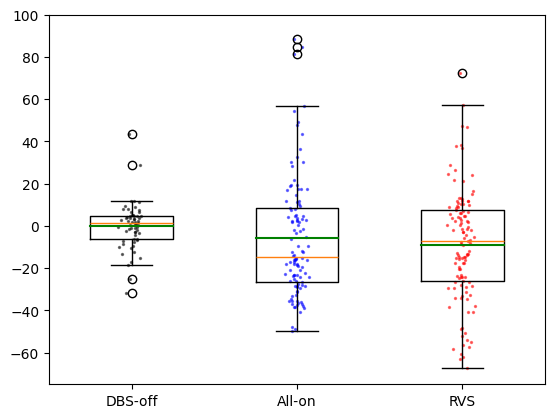

==============mean 13-20===============

DBS-off Mean:  0.26 
DBS-off SEM:  8.71 
DBS-off CI:  [ -14.06 ,  14.58 ]


All-on Mean:  4.67 
All-on SEM:  7.41 
All-on CI:  [ -7.78 ,  16.6 ]


RVS Mean:  -9.82 
RVS SEM:  7.41 
RVS CI:  [ -22.27 ,  2.12 ]


DBS-off vs. All-on:  0.5519 
DBS-off vs. RVS:  0.1742 
All-on vs. RVS:  0.0167 

                             Mixed Linear Model Regression Results
Model:                         MixedLM              Dependent Variable:              Outcome   
No. Observations:              294                  Method:                          REML      
No. Groups:                    12                   Scale:                           1099.0616 
Min. group size:               15                   Log-Likelihood:                  -1437.3822
Max. group size:               30                   Converged:                       Yes       
Mean group size:               24.5                                                            
------------------------

C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:60: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "\nDBS-off CI: ",      "[",round1000(ci[0][0]),", ",round1000(ci[1][0]),"]"\
C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "\nAll-on CI: ",      "[",round1000(ci[0][1]),", ",round1000(ci[1][1]),"]"\
C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:68: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior

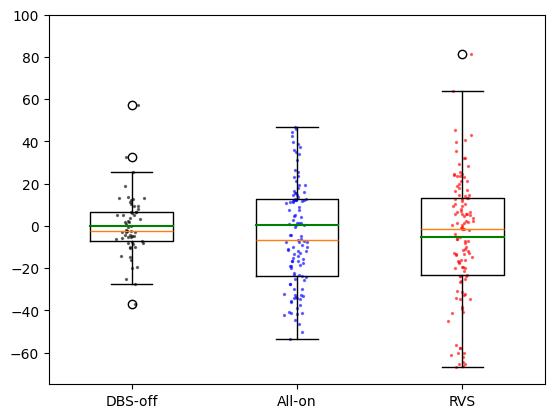

==============mean 20-30===============

DBS-off Mean:  4.92 
DBS-off SEM:  10.82 
DBS-off CI:  [ -12.88 ,  22.71 ]


All-on Mean:  -0.37 
All-on SEM:  4.85 
All-on CI:  [ -13.26 ,  2.69 ]


RVS Mean:  -11.46 
RVS SEM:  4.85 
RVS CI:  [ -24.35 ,  -8.41 ]


DBS-off vs. All-on:  0.2759 
DBS-off vs. RVS:  0.0007 
All-on vs. RVS:  0.0051 

                             Mixed Linear Model Regression Results
Model:                         MixedLM              Dependent Variable:              Outcome   
No. Observations:              294                  Method:                          REML      
No. Groups:                    12                   Scale:                           470.0666  
Min. group size:               15                   Log-Likelihood:                  -1323.3553
Max. group size:               30                   Converged:                       Yes       
Mean group size:               24.5                                                            
-------------------

C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:60: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "\nDBS-off CI: ",      "[",round1000(ci[0][0]),", ",round1000(ci[1][0]),"]"\
C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "\nAll-on CI: ",      "[",round1000(ci[0][1]),", ",round1000(ci[1][1]),"]"\
C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:68: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior

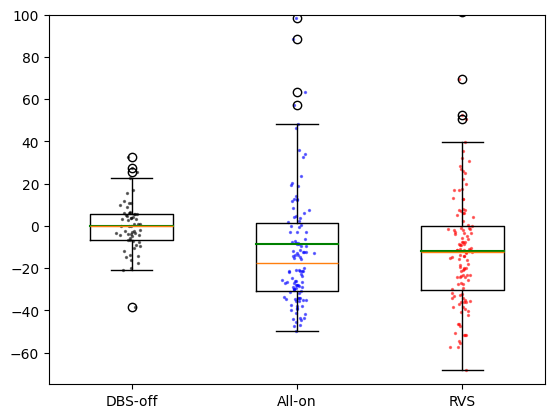

In [3]:
p1 = 13
p2 = 30
print("==============mean 13-30===============")
data = copy.deepcopy(df_all)
dataReturn = gen_DataSlice(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= False)
#model = smf.mixedlm("Outcome ~ Condition", data=dataReturn, groups=dataReturn["Participant"]).fit()
model = smf.mixedlm( "Outcome ~ Condition * Period", data=dataReturn, groups=dataReturn["Participant"]).fit()
statoutLMEM(model)
print(model.summary(alpha=0.10))

baseValues, baseMeans, allValues, allMeans, rvsValues, rvsMeans = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= False)
custombox( baseValues,1, scatter = True, sds = False, w = [.5])
custombox( allValues,2, scatter = True,  sds = False, w = [.5], color = 'b')
custombox( rvsValues,3, scatter = True,  sds = False, w = [.5], color = 'r')
plt.xticks([1,2,3],labels = ["DBS-off","All-on","RVS"])
plt.ylim([-75,100])
exportFigure("Mean_13_30_Fig2A")
plt.show()


p1 = 13
p2 = 20
print("==============mean 13-20===============")
data = copy.deepcopy(df_all)
dataReturn = gen_DataSlice(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= False)
#model = smf.mixedlm("Outcome ~ Condition", data=dataReturn, groups=dataReturn["Participant"]).fit()
model = smf.mixedlm( "Outcome ~ Condition * Period", data=dataReturn, groups=dataReturn["Participant"]).fit()
statoutLMEM(model)
print(model.summary(alpha=0.10))

baseValues, baseMeans, allValues, allMeans, rvsValues, rvsMeans = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= False)
custombox( baseValues,1, scatter = True, sds = False, w = [.5])
custombox( allValues,2, scatter = True,  sds = False, w = [.5], color = 'b')
custombox( rvsValues,3, scatter = True,  sds = False, w = [.5], color = 'r')
plt.xticks([1,2,3],labels = ["DBS-off","All-on","RVS"])
plt.ylim([-75,100])
exportFigure("Mean_13_20_Fig2B")
plt.show()


p1 = 20
p2 = 30
print("==============mean 20-30===============")
data = copy.deepcopy(df_all)
dataReturn = gen_DataSlice(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= False)
#model = smf.mixedlm("Outcome ~ Condition", data=dataReturn, groups=dataReturn["Participant"]).fit()
model = smf.mixedlm( "Outcome ~ Condition * Period", data=dataReturn, groups=dataReturn["Participant"]).fit()
statoutLMEM(model)
print(model.summary(alpha=0.10))

baseValues, baseMeans, allValues, allMeans, rvsValues, rvsMeans = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= False)
custombox( baseValues,1, scatter = True, sds = False, w = [.5])
custombox( allValues,2, scatter = True,  sds = False, w = [.5], color = 'b')
custombox( rvsValues,3, scatter = True,  sds = False, w = [.5], color = 'r')
plt.xticks([1,2,3],labels = ["DBS-off","All-on","RVS"])
plt.ylim([-75,100])
exportFigure("Mean_20_30_Fig2C")
plt.show()

## Figure 2 D, E, F

==============max 13-30===============


C:\Users\Jesse\Anaconda3\envs\PDCLinic_Analysis\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Jesse\Anaconda3\envs\PDCLinic_Analysis\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:60: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "\nDBS-off CI: ",      "[",round1000(ci[0][0]),", ",round1000(ci[1][0]),"]"\
C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys wi


DBS-off Mean:  127.14 
DBS-off SEM:  19.94 
DBS-off CI:  [ 94.33 ,  159.94 ]


All-on Mean:  112.37 
All-on SEM:  18.8 
All-on CI:  [ -45.69 ,  16.16 ]


RVS Mean:  66.19 
RVS SEM:  18.8 
RVS CI:  [ -91.87 ,  -30.02 ]


DBS-off vs. All-on:  0.4322 
DBS-off vs. RVS:  0.0012 
All-on vs. RVS:  0.0026 

                             Mixed Linear Model Regression Results
Model:                          MixedLM              Dependent Variable:              Outcome   
No. Observations:               294                  Method:                          REML      
No. Groups:                     12                   Scale:                           7070.6520 
Min. group size:                15                   Log-Likelihood:                  -1703.6676
Max. group size:                30                   Converged:                       Yes       
Mean group size:                24.5                                                            
-------------------------------------------------

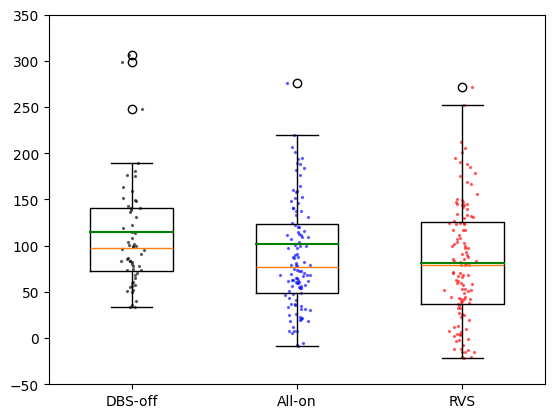

==============max 13-20===============

DBS-off Mean:  75.23 
DBS-off SEM:  18.92 
DBS-off CI:  [ 44.11 ,  106.35 ]


All-on Mean:  69.77 
All-on SEM:  18.38 
All-on CI:  [ -35.68 ,  24.77 ]


RVS Mean:  31.04 
RVS SEM:  18.38 
RVS CI:  [ -74.42 ,  -13.96 ]


DBS-off vs. All-on:  0.7666 
DBS-off vs. RVS:  0.0162 
All-on vs. RVS:  0.0098 

                             Mixed Linear Model Regression Results
Model:                          MixedLM              Dependent Variable:              Outcome   
No. Observations:               294                  Method:                          REML      
No. Groups:                     12                   Scale:                           6754.2135 
Min. group size:                15                   Log-Likelihood:                  -1696.4964
Max. group size:                30                   Converged:                       Yes       
Mean group size:                24.5                                                            
----------

C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:60: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "\nDBS-off CI: ",      "[",round1000(ci[0][0]),", ",round1000(ci[1][0]),"]"\
C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "\nAll-on CI: ",      "[",round1000(ci[0][1]),", ",round1000(ci[1][1]),"]"\
C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:68: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior

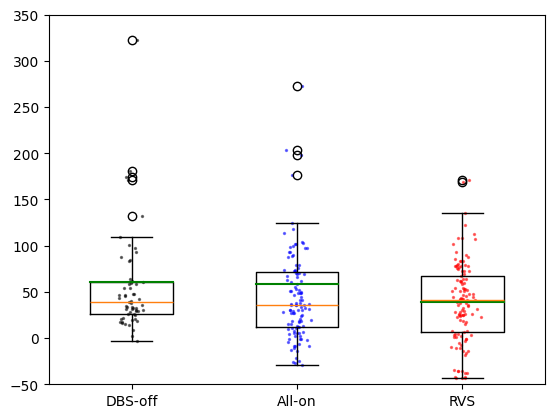

==============max 20-30 ===============

DBS-off Mean:  91.47 
DBS-off SEM:  19.84 
DBS-off CI:  [ 58.84 ,  124.1 ]


All-on Mean:  69.49 
All-on SEM:  10.74 
All-on CI:  [ -39.66 ,  -4.32 ]


RVS Mean:  43.81 
RVS SEM:  10.74 
RVS CI:  [ -65.33 ,  -29.99 ]


DBS-off vs. All-on:  0.0407 
DBS-off vs. RVS:  0.0 
All-on vs. RVS:  0.0034 

                              Mixed Linear Model Regression Results
Model:                           MixedLM              Dependent Variable:              Outcome   
No. Observations:                294                  Method:                          REML      
No. Groups:                      12                   Scale:                           2308.1891 
Min. group size:                 15                   Log-Likelihood:                  -1550.3313
Max. group size:                 30                   Converged:                       Yes       
Mean group size:                 24.5                                                            
------

C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:60: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "\nDBS-off CI: ",      "[",round1000(ci[0][0]),", ",round1000(ci[1][0]),"]"\
C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "\nAll-on CI: ",      "[",round1000(ci[0][1]),", ",round1000(ci[1][1]),"]"\
C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:68: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior

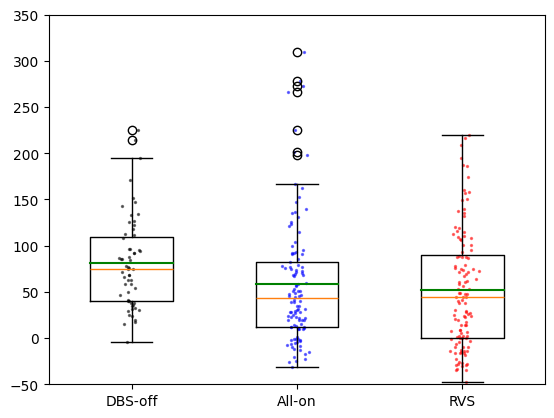

In [4]:
p1 = 13
p2 = 30
print("==============max 13-30===============")
data = copy.deepcopy(df_all)
dataReturn = gen_DataSlice(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= True)
#model = smf.mixedlm("Outcome ~ Condition", data=dataReturn, groups=dataReturn["Participant"]).fit()
model = smf.mixedlm( "Outcome ~ Condition * Period", data=dataReturn, groups=dataReturn["Participant"]).fit()
statoutLMEM(model)
print(model.summary(alpha=0.10))

baseValues, baseMeans, allValues, allMeans, rvsValues, rvsMeans = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= True)
custombox( baseValues,1, scatter = True, sds = False, w = [.5])
custombox( allValues,2, scatter = True,  sds = False, w = [.5], color = 'b')
custombox( rvsValues,3, scatter = True,  sds = False, w = [.5], color = 'r')
plt.xticks([1,2,3],labels = ["DBS-off","All-on","RVS"])
plt.ylim([-50,350])
exportFigure("Max_13_30_Fig2D")
plt.show()

p1 = 13
p2 = 20
print("==============max 13-20===============")
data = copy.deepcopy(df_all)
dataReturn = gen_DataSlice(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= True)
#model = smf.mixedlm("Outcome ~ Condition", data=dataReturn, groups=dataReturn["Participant"]).fit()
model = smf.mixedlm( "Outcome ~ Condition * Period", data=dataReturn, groups=dataReturn["Participant"]).fit()
statoutLMEM(model)
print(model.summary(alpha=0.10))

baseValues, baseMeans, allValues, allMeans, rvsValues, rvsMeans = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= True)
custombox( baseValues,1, scatter = True, sds = False, w = [.5])
custombox( allValues,2, scatter = True,  sds = False, w = [.5], color = 'b')
custombox( rvsValues,3, scatter = True,  sds = False, w = [.5], color = 'r')
plt.xticks([1,2,3],labels = ["DBS-off","All-on","RVS"])
plt.ylim([-50,350])
exportFigure("Max_13_20_Fig2E")
plt.show()



p1 = 20
p2 = 30
print("==============max 20-30 ===============")
data = copy.deepcopy(df_all)
dataReturn = gen_DataSlice(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= True)
#model = smf.mixedlm("Outcome ~ Condition", data=dataReturn, groups=dataReturn["Participant"]).fit()
model = smf.mixedlm( "Outcome ~ Condition * Period", data=dataReturn, groups=dataReturn["Participant"]).fit()
statoutLMEM(model)
print(model.summary(alpha=0.10))

baseValues, baseMeans, allValues, allMeans, rvsValues, rvsMeans = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= True)
custombox( baseValues,1, scatter = True, sds = False, w = [.5])
custombox( allValues,2, scatter = True,  sds = False, w = [.5], color = 'b')
custombox( rvsValues,3, scatter = True,  sds = False, w = [.5], color = 'r')
plt.xticks([1,2,3],labels = ["DBS-off","All-on","RVS"])
plt.ylim([-50,350])
exportFigure("Max_20_30_Fig2F")
plt.show()

## Figure 2 G, H

==============mean===============
['dbs_off,all_on,rvs' 'dbs_off,rvs,all_on']

DBS-off Mean:  0.0 
DBS-off SEM:  7.95 
DBS-off CI:  [ -13.08 ,  13.08 ]


All-on Mean:  1.22 
All-on SEM:  5.63 
All-on CI:  [ -8.04 ,  10.48 ]


RVS Mean:  -15.07 
RVS SEM:  5.63 
RVS CI:  [ -24.33 ,  -5.81 ]


DBS-off vs. All-on:  0.8281 
DBS-off vs. RVS:  0.0074 
All-on vs. RVS:  0.0004 

                             Mixed Linear Model Regression Results
Model:                          MixedLM              Dependent Variable:              Outcome  
No. Observations:               177                  Method:                          REML     
No. Groups:                     12                   Scale:                           380.5171 
Min. group size:                12                   Log-Likelihood:                  -772.5362
Max. group size:                15                   Converged:                       Yes      
Mean group size:                14.8                                            

C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:60: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "\nDBS-off CI: ",      "[",round1000(ci[0][0]),", ",round1000(ci[1][0]),"]"\
C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "\nAll-on CI: ",      "[",round1000(ci[0][1]),", ",round1000(ci[1][1]),"]"\
C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:68: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior

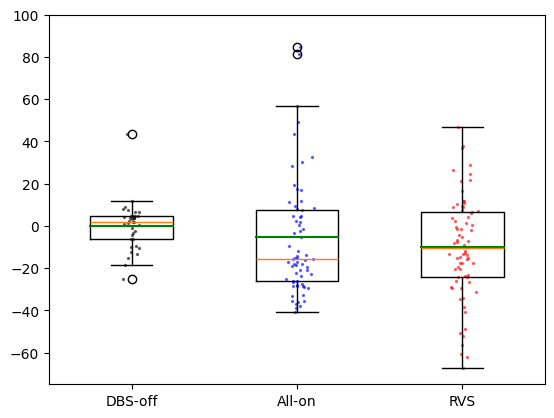

C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:60: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "\nDBS-off CI: ",      "[",round1000(ci[0][0]),", ",round1000(ci[1][0]),"]"\
C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "\nAll-on CI: ",      "[",round1000(ci[0][1]),", ",round1000(ci[1][1]),"]"\
C:\Users\Jesse\AppData\Local\Temp\ipykernel_43496\973461364.py:68: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior

==============mean===============
['dbs_off,all_on,rvs' 'dbs_off,rvs,all_on']

DBS-off Mean:  0.0 
DBS-off SEM:  11.25 
DBS-off CI:  [ -18.5 ,  18.5 ]


All-on Mean:  -9.85 
All-on SEM:  7.42 
All-on CI:  [ -22.05 ,  2.35 ]


RVS Mean:  -13.08 
RVS SEM:  7.42 
RVS CI:  [ -25.28 ,  -0.88 ]


DBS-off vs. All-on:  0.184 
DBS-off vs. RVS:  0.0778 
All-on vs. RVS:  0.5941 

                             Mixed Linear Model Regression Results
Model:                          MixedLM              Dependent Variable:              Outcome  
No. Observations:               117                  Method:                          REML     
No. Groups:                     8                    Scale:                           440.0393 
Min. group size:                12                   Log-Likelihood:                  -511.7639
Max. group size:                15                   Converged:                       Yes      
Mean group size:                14.6                                             

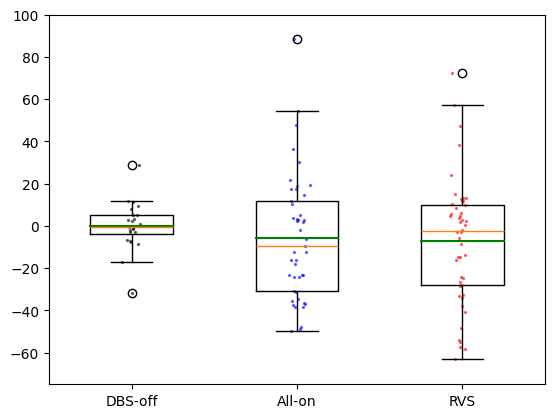

In [5]:
p1 = 13
p2 = 30

data = copy.deepcopy(df_all)
data = data[(data["IpsiContra"] == "contra")]
print("==============mean===============")
dataReturn = gen_DataSlice(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= False)
print(np.unique(dataReturn["Period"]))
model = smf.mixedlm( "Outcome ~ Condition * Period", data=dataReturn, groups=dataReturn["Participant"]).fit()
statoutLMEM(model)
print(model.summary(alpha=0.10))

baseValues, baseMeans, allValues, allMeans, rvsValues, rvsMeans = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= False)
custombox( baseValues,1, scatter = True, sds = False, w = [.5])
custombox( allValues,2, scatter = True,  sds = False, w = [.5], color = 'b')
custombox( rvsValues,3, scatter = True,  sds = False, w = [.5], color = 'r')
plt.xticks([1,2,3],labels = ["DBS-off","All-on","RVS"])
plt.ylim([-75,100])
exportFigure("Mean_13_20_Contra_Fig2G")
plt.show()

data = copy.deepcopy(df_all)
data = data[(data["IpsiContra"] == "ipsi")]
print("==============mean===============")
dataReturn = gen_DataSlice(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= False)
print(np.unique(dataReturn["Period"]))
model = smf.mixedlm( "Outcome ~ Condition * Period", data=dataReturn, groups=dataReturn["Participant"]).fit()
statoutLMEM(model)
print(model.summary(alpha=0.10))

baseValues, baseMeans, allValues, allMeans, rvsValues, rvsMeans = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= False)
custombox( baseValues,1, scatter = True, sds = False, w = [.5])
custombox( allValues,2, scatter = True,  sds = False, w = [.5], color = 'b')
custombox( rvsValues,3, scatter = True,  sds = False, w = [.5], color = 'r')
plt.xticks([1,2,3],labels = ["DBS-off","All-on","RVS"])
plt.ylim([-75,100])
exportFigure("Mean_13_20_Ipsi_Fig2I")
plt.show()